In [176]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('CarPrice_Assignment.csv')

In [9]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [13]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [15]:
df.duplicated().sum()

0

In [17]:
df = df.drop(columns=['car_ID', 'CarName'])

In [19]:
df.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


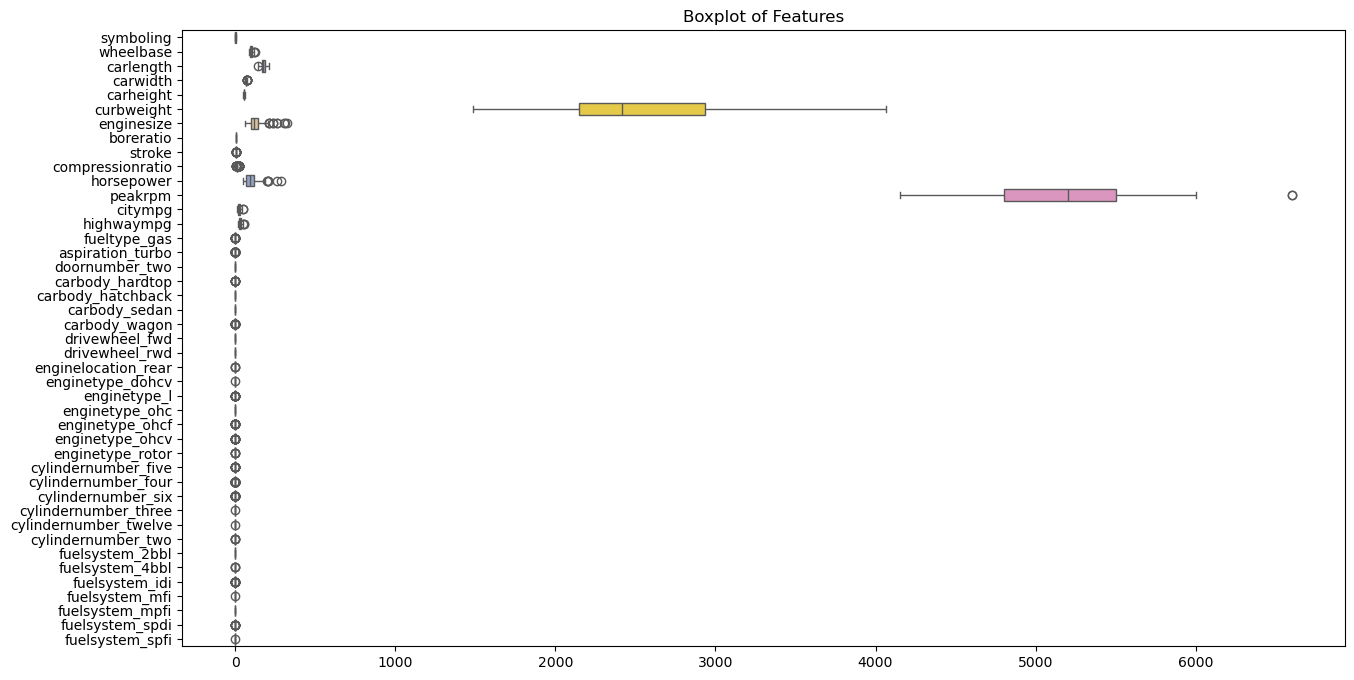

In [83]:
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(data=df.drop('price', axis=1), orient="h", palette="Set2")
plt.title("Boxplot of Features")
plt.show()

In [85]:
#Encoding Categorical Variables

In [22]:
df = pd.get_dummies(df, drop_first=True)

In [24]:
df.head()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,True,False,False
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,True,False,False
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,False,False,False,False,False,False,False,True,False,False
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,False,False,False,False,False,False,False,True,False,False
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,False,False,False,False,False,False,False,True,False,False


In [26]:
X = df.drop('price', axis=1)
y = df['price']

In [28]:
#training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
X_train.shape, X_test.shape

((164, 43), (41, 43))

# Step 2: Model Implementation


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(),
    "Support Vector Regressor": SVR()
}

In [66]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(),
    "Support Vector Regressor": SVR()
}

In [72]:
results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results[model_name] = {"R2": r2, "MSE": mse, "MAE": mae}
# dataframe of results
results_df = pd.DataFrame(results).T
results_df.sort_values(by="R2", ascending=False)

,R2,MSE,MAE
Random Forest Regressor,0.954736,3.573317e+06,1303.540134
Gradient Boosting Regressor,0.923554,6.034948e+06,1725.617988
Decision Tree Regressor,0.906072,7.415075e+06,1836.142268
Linear Regression,0.892557,8.482008e+06,2089.382729
Support Vector Regressor,-0.101973,8.699416e+07,5707.106446


# Step 3: Model Evaluation

In [75]:
import matplotlib.pyplot as plt

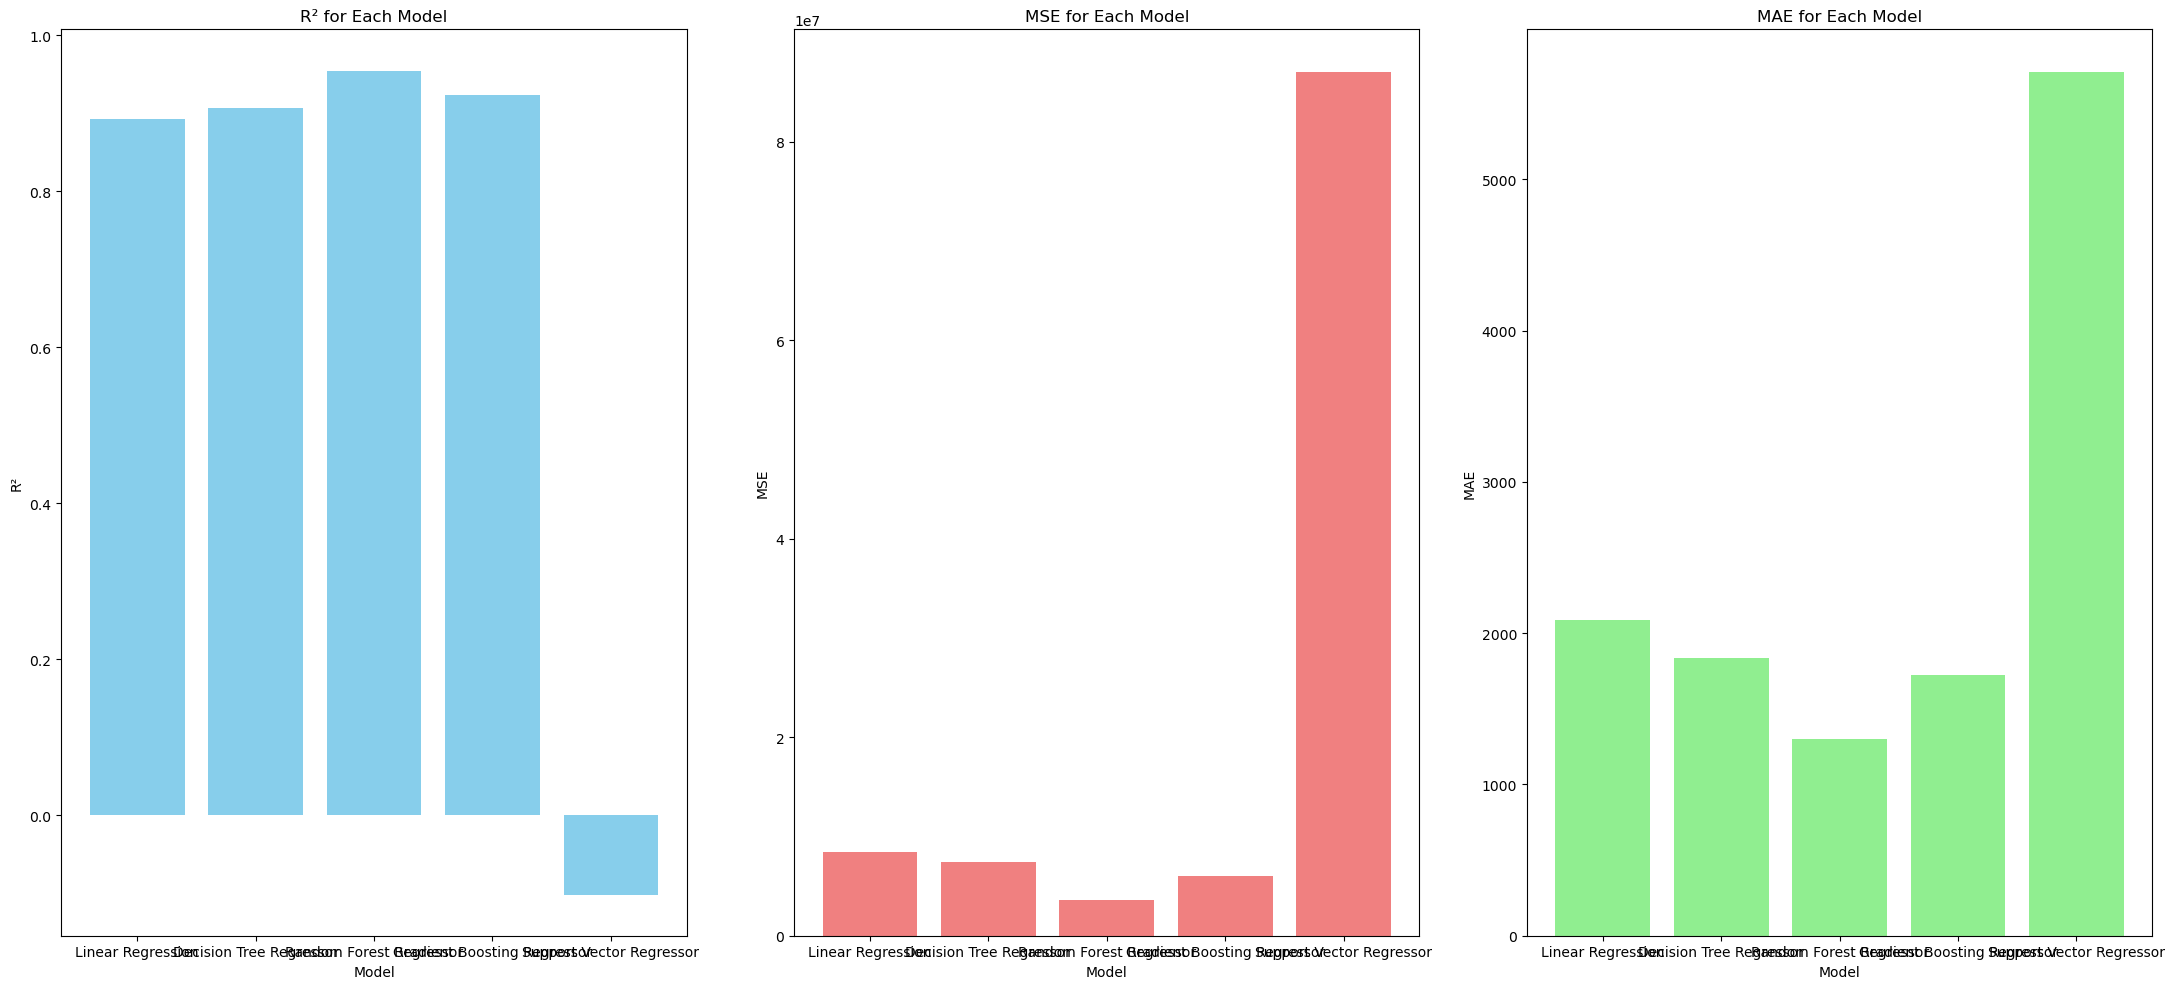

In [79]:
#plotting for each model
fig, ax = plt.subplots(1, 3, figsize=(22, 10))
# R² Plot
ax[0].bar(results_df.index, results_df['R2'], color='skyblue')
ax[0].set_title('R² for Each Model')
ax[0].set_xlabel('Model')
ax[0].set_ylabel('R²')

# MSE Plot
ax[1].bar(results_df.index, results_df['MSE'], color='lightcoral')
ax[1].set_title('MSE for Each Model')
ax[1].set_xlabel('Model')
ax[1].set_ylabel('MSE')

# MAE Plot
ax[2].bar(results_df.index, results_df['MAE'], color='lightgreen')
ax[2].set_title('MAE for Each Model')
ax[2].set_xlabel('Model')
ax[2].set_ylabel('MAE')

plt.tight_layout()
plt.show()

# Step 4: Feature Importance Analysis

In [90]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

RandomForestRegressor()

In [92]:
feature_importances = rf_model.feature_importances_

In [94]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

In [96]:
importance_df = importance_df.sort_values(by='Importance', ascending=False)

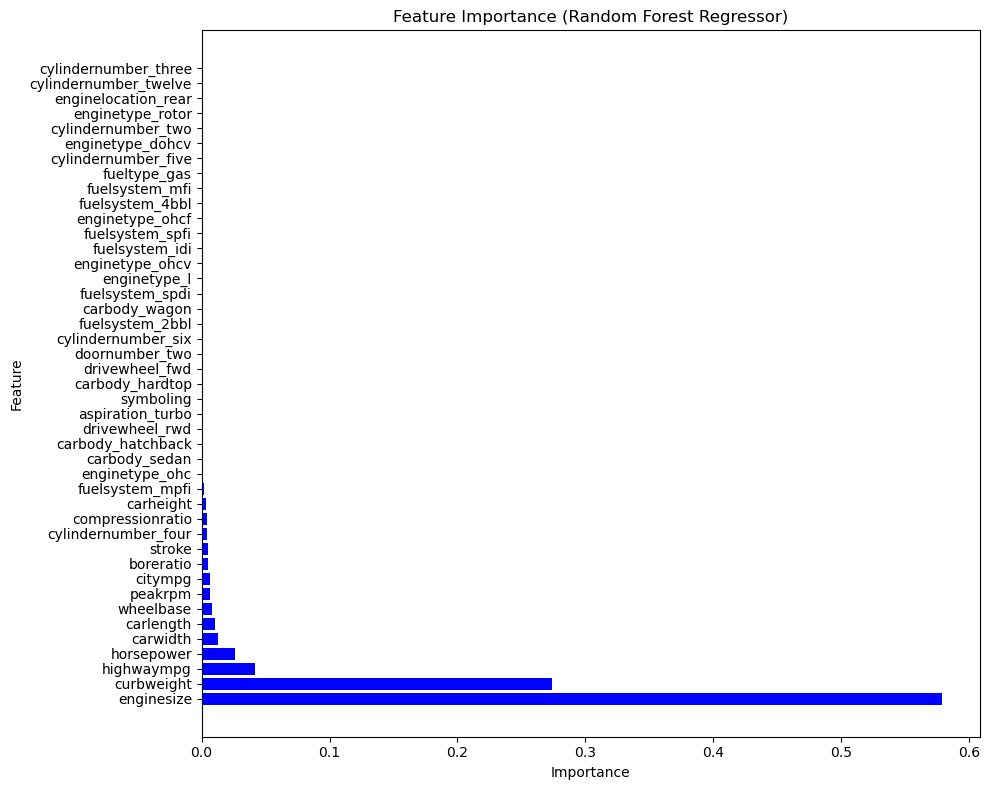

In [122]:
# Plot the feature importances
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='blue')
plt.title('Feature Importance (Random Forest Regressor)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [124]:
print(importance_df.head(10))

       Feature  Importance
6   enginesize    0.579325
5   curbweight    0.273784
13  highwaympg    0.042037
10  horsepower    0.026126
3     carwidth    0.013069
2    carlength    0.010125
1    wheelbase    0.007941
11     peakrpm    0.006864
12     citympg    0.006583
7    boreratio    0.005268


In [128]:
# Select top 10 most important features
top_10_features = importance_df.head(10)['Feature']
X_train_selected = X_train[top_10_features]
X_test_selected = X_test[top_10_features]

# Train a model with selected features
rf_model_selected = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model_selected.fit(X_train_selected, y_train)

# Evaluate performance
y_pred_selected = rf_model_selected.predict(X_test_selected)
mse_selected = mean_squared_error(y_test, y_pred_selected)
r2_selected = r2_score(y_test, y_pred_selected)
print(f"Mean Squared Error (MSE) after feature selection: {mse_selected}")
print(f"R-squared after feature selection: {r2_selected}")

Mean Squared Error (MSE) after feature selection: 3328739.166957864
R-squared after feature selection: 0.9578341826288251


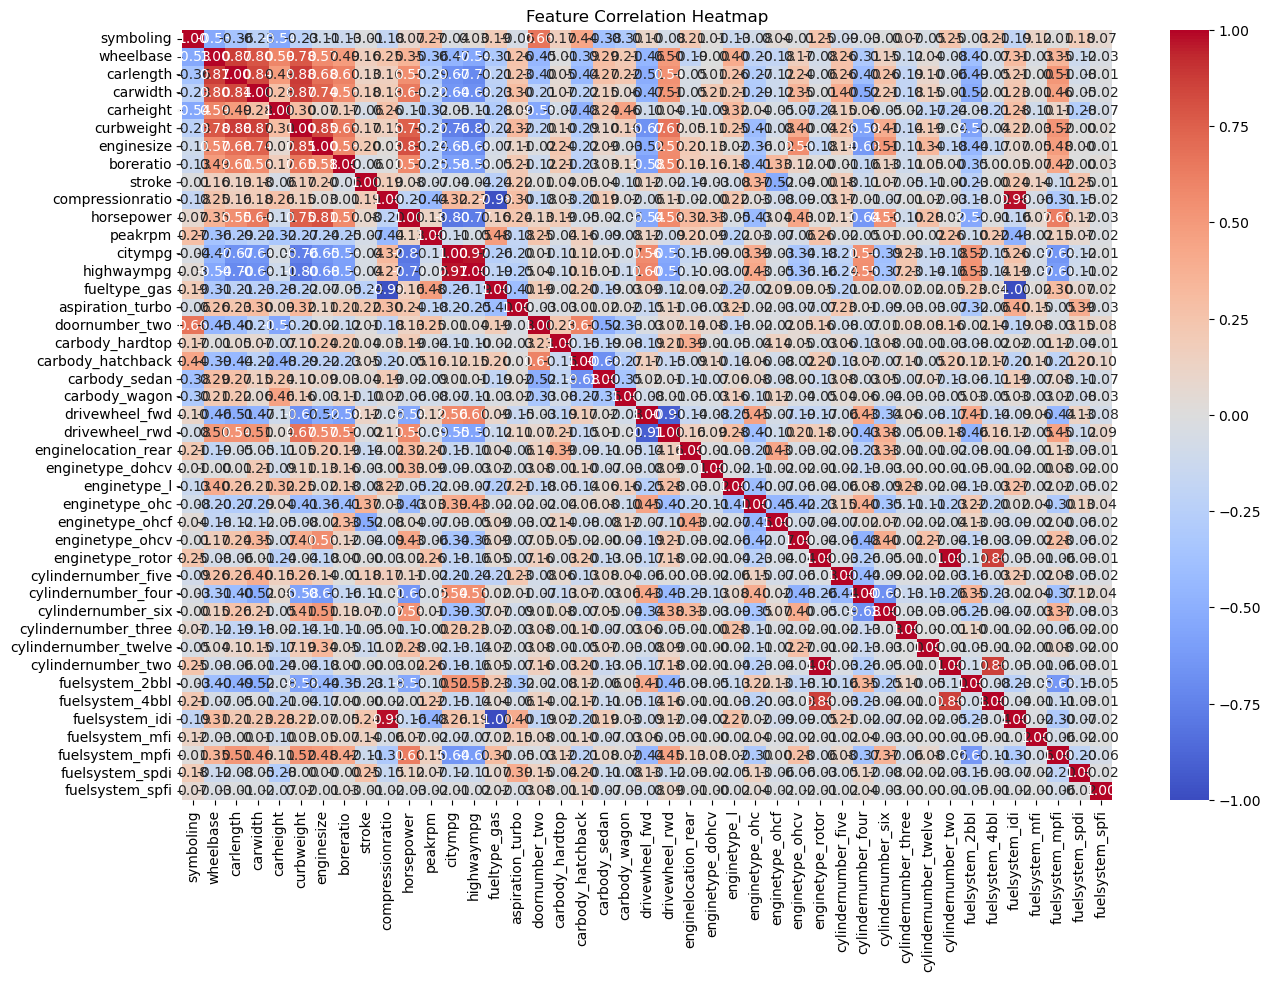

In [137]:
# Correlation heatmap
corr = X.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()


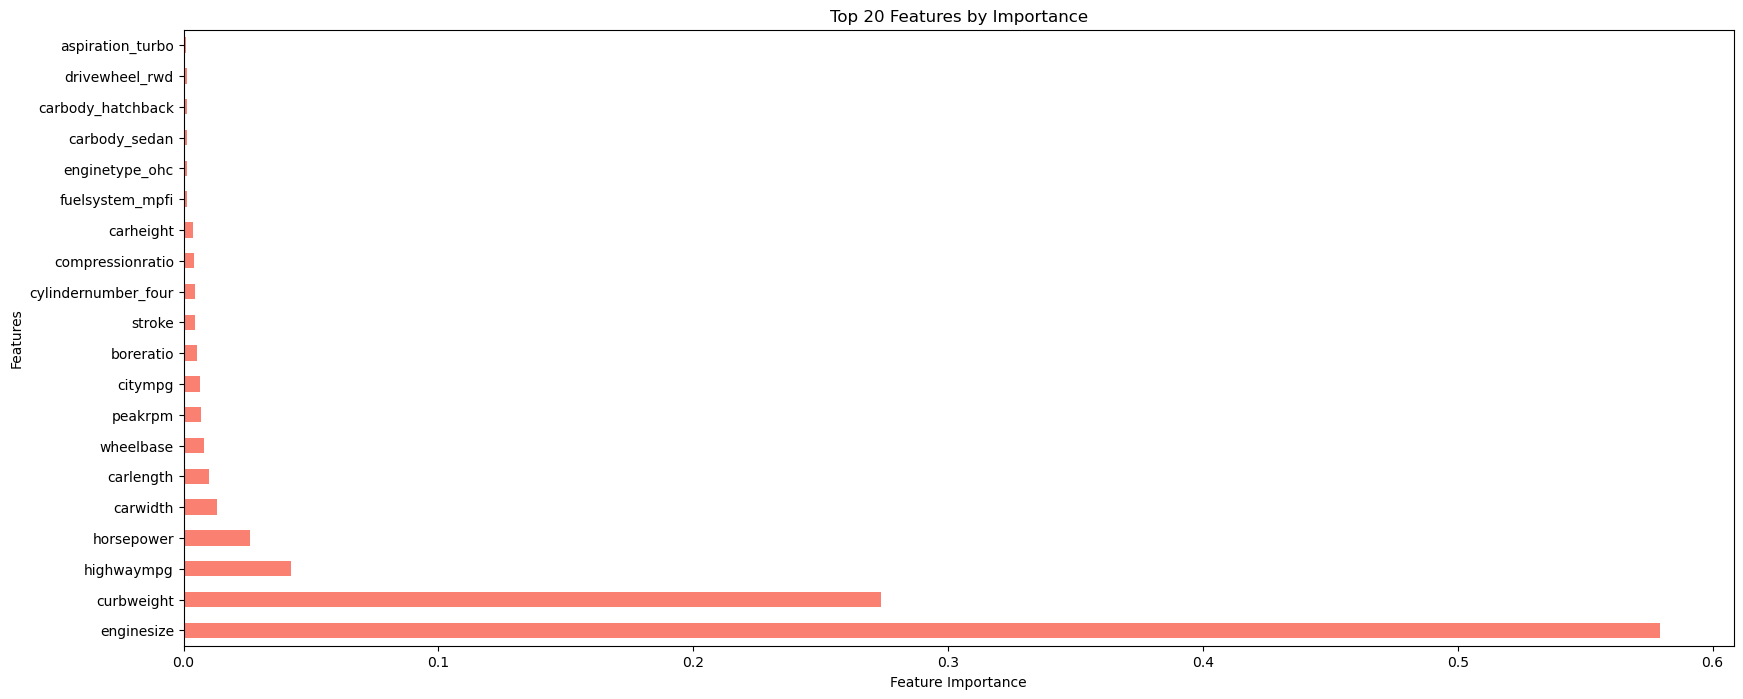

In [143]:
# Feature importance visualization
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(20, 8))
feature_importance.nlargest(20).plot(kind='barh', color='salmon')
plt.title('Top 20 Features by Importance')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.show()

# Step 5: Hyperparameter Tuning

In [178]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

print("Best Parameters: ", grid_search.best_params_)
print("Best Score (MSE): ", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)


# Evaluate the performance
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE) after tuning: {mse}")
print(f"R-squared after tuning: {r2}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters:  {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Score (MSE):  -5070618.928386438
Mean Squared Error (MSE) after tuning: 4617427.737384612
R-squared after tuning: 0.941510101893297


# Model Deployment

In [156]:
best_model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=1)
best_model.fit(X_train, y_train)
final_predictions = best_model.predict(X_test)

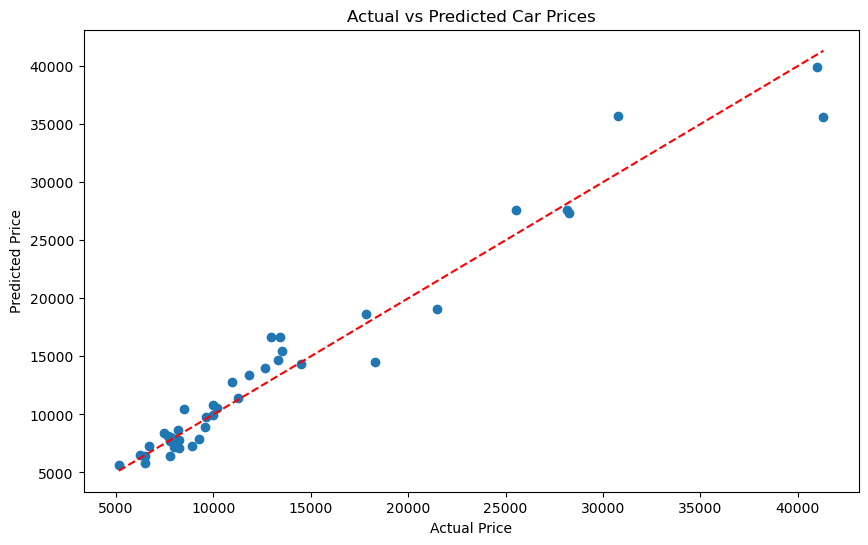

In [158]:
# Plot the actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, final_predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Actual vs Predicted Car Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

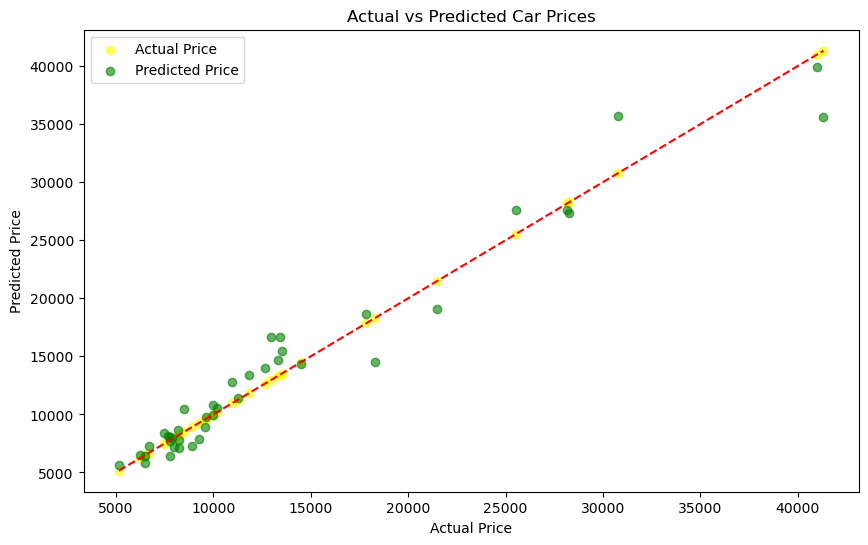

In [174]:
# Plot the actual vs predicted prices
plt.figure(figsize=(10, 6))
# yellow dots
plt.scatter(y_test, y_test, color='yellow', label='Actual Price', alpha=0.6)
# red dots
plt.scatter(y_test, final_predictions, color='green', label='Predicted Price', alpha=0.6)
# Plot the perfect prediction line (Red dashed line)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
# Add labels and title
plt.title('Actual vs Predicted Car Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
# Show legend
plt.legend()
plt.show()